# day4_nb_evaluation.ipynb

# Día 4: evaluación del modelo para `dedo`

## Objetivo

En este cuaderno vamos a evaluar el modelo usado en la app final del curso.

La idea es reutilizar exactamente la misma estrategia base:

- recorte y rectificación automática del panel negro;
- embeddings globales con `DINOv2`;
- regresión logística sobre esos embeddings;
- evaluación sobre un conjunto de test separado.

Nos centraremos en las métricas vistas en las transparencias de evaluación, siempre que tengan sentido para este problema binario:

- matriz de confusión;
- accuracy;
- precision;
- recall;
- F1-score;
- sensibilidad;
- especificidad;
- curva ROC y AUC;
- curva Precision-Recall y Average Precision.

## Instalación

```bash
pip install pandas numpy scikit-learn pillow timm torch torchvision opencv-python matplotlib seaborn
```

## Importaciones

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torchvision import transforms
from tqdm.auto import tqdm

from day1_opencv_helpers import (
    detect_black_panel,
    normalize_with_white_background,
    orient_panel_to_left,
    segment_hand,
    warp_panel,
)

## Configuración general

Usamos los mismos parámetros que en la app final para que la evaluación sea coherente con la demo.

In [25]:
RUTA_DATA = Path("data/dedo")
RANDOM_STATE = 42
TEST_SIZE = 0.25
PANEL_SIZE = (640, 480)
TARGET_BACKGROUND_GRAY = 200
TARGET_BOX_GRAY = 25
DARK_BOX_THRESHOLD = 25
PANEL_DETECTION_THRESHOLD = 70
POSITIVE_LABEL = "si"
NEGATIVE_LABEL = "no"

## Cargar el dataset

In [26]:
registros = []

for etiqueta_dir in sorted(RUTA_DATA.iterdir()):
    if not etiqueta_dir.is_dir():
        continue
    for ruta in sorted(etiqueta_dir.glob("*.png")):
        registros.append(
            {
                "ruta": str(ruta),
                "etiqueta": etiqueta_dir.name,
                "archivo": ruta.name,
            }
        )

datos = pd.DataFrame(registros)
datos.head()

,ruta,etiqueta,archivo
0,data\dedo\no\img_1776863541097.png,no,img_1776863541097.png
1,data\dedo\no\img_1776863844568.png,no,img_1776863844568.png
2,data\dedo\no\img_1776863884377.png,no,img_1776863884377.png
3,data\dedo\no\img_1776863887385.png,no,img_1776863887385.png
4,data\dedo\no\img_1776863902961.png,no,img_1776863902961.png


In [27]:
datos.groupby("etiqueta").size().rename("n").reset_index()

,etiqueta,n
0,no,37
1,si,44


## Separación train/test

Usamos una división estratificada y reproducible.

In [28]:
train_df, test_df = train_test_split(
    datos,
    test_size=TEST_SIZE,
    stratify=datos["etiqueta"],
    random_state=RANDOM_STATE,
)

train_df = train_df.reset_index(drop=True).copy()
test_df = test_df.reset_index(drop=True).copy()

pd.crosstab(
    pd.Series(["train"] * len(train_df) + ["test"] * len(test_df), name="split"),
    pd.concat([train_df["etiqueta"], test_df["etiqueta"]], ignore_index=True),
    margins=True,
)

etiqueta,no,si,All
split,,,
test,10,11,21
train,27,33,60
All,37,44,81


## Preprocesado geométrico

Reutilizamos exactamente la misma función de recorte del panel rectificado.

In [29]:
def extract_panel_pil(image):
    rgb = np.array(image.convert("RGB"))
    normalized, _, _ = normalize_with_white_background(
        rgb,
        target_background_gray=TARGET_BACKGROUND_GRAY,
        target_box_gray=TARGET_BOX_GRAY,
        dark_box_threshold=DARK_BOX_THRESHOLD,
    )
    quad, _, _ = detect_black_panel(
        normalized,
        panel_threshold=PANEL_DETECTION_THRESHOLD,
    )
    panel, _ = warp_panel(normalized, quad, output_size=PANEL_SIZE)
    hand_mask, _ = segment_hand(
        panel,
        hand_background_threshold=120,
        hand_light_threshold=200,
    )
    panel, _, _ = orient_panel_to_left(panel, hand_mask)
    return Image.fromarray(panel)


def cargar_pil(ruta):
    return Image.open(ruta).convert("RGB")

## Preparar imágenes originales y crop

In [30]:
train_df["image"] = train_df["ruta"].map(cargar_pil)
train_df["image_crop"] = train_df["image"].map(extract_panel_pil)

test_df["image"] = test_df["ruta"].map(cargar_pil)
test_df["image_crop"] = test_df["image"].map(extract_panel_pil)

train_df.head()

,ruta,etiqueta,archivo,image,image_crop
0,data\dedo\no\img_1776863887385.png,no,img_1776863887385.png,<PIL.Image.Image image mode=RGB size=640x480 a...,<PIL.Image.Image image mode=RGB size=640x480 a...
1,data\dedo\no\img_1777028310895.png,no,img_1777028310895.png,<PIL.Image.Image image mode=RGB size=640x480 a...,<PIL.Image.Image image mode=RGB size=640x480 a...
2,data\dedo\si\img_1777027592482.png,si,img_1777027592482.png,<PIL.Image.Image image mode=RGB size=640x480 a...,<PIL.Image.Image image mode=RGB size=640x480 a...
3,data\dedo\si\img_1776864612420.png,si,img_1776864612420.png,<PIL.Image.Image image mode=RGB size=640x480 a...,<PIL.Image.Image image mode=RGB size=640x480 a...
4,data\dedo\si\img_1777028190117.png,si,img_1777028190117.png,<PIL.Image.Image image mode=RGB size=640x480 a...,<PIL.Image.Image image mode=RGB size=640x480 a...


## Inspeccionar un ejemplo

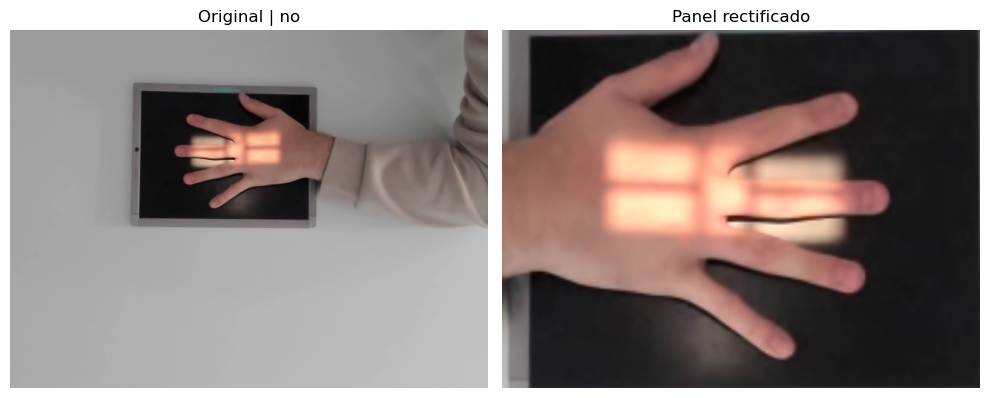

In [31]:
sample_row = test_df.iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_row["image"])
axes[0].set_title(f"Original | {sample_row['etiqueta']}")
axes[0].axis("off")

axes[1].imshow(sample_row["image_crop"])
axes[1].set_title("Panel rectificado")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Cargar DINOv2

Usamos el mismo backbone visual que en la app final: `vit_small_patch14_dinov2.lvd142m`.

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dino_model = timm.create_model(
    "vit_small_patch14_dinov2.lvd142m",
    pretrained=True,
    num_classes=0,
)
dino_model = dino_model.to(device)
dino_model.eval()

dino_image_size = dino_model.patch_embed.img_size[0]

dino_transform = transforms.Compose(
    [
        transforms.Resize((dino_image_size, dino_image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
    ]
)

dino_image_size

518

## Extraer embeddings

In [33]:
def extract_embeddings(df, model, transform, image_column="image_crop", batch_size=16):
    all_embeddings = []

    with torch.inference_mode():
        for start in tqdm(range(0, len(df), batch_size), desc="Extrayendo embeddings"):
            batch_images = df.iloc[start:start + batch_size][image_column].tolist()
            batch_tensor = torch.stack([transform(image) for image in batch_images]).to(device)
            batch_embeddings = model(batch_tensor).cpu().numpy()
            all_embeddings.append(batch_embeddings)

    return np.vstack(all_embeddings)

In [34]:
X_train = extract_embeddings(train_df, dino_model, dino_transform, image_column="image_crop")
X_test = extract_embeddings(test_df, dino_model, dino_transform, image_column="image_crop")

y_train = train_df["etiqueta"].to_numpy()
y_test = test_df["etiqueta"].to_numpy()

X_train.shape, X_test.shape

Extrayendo embeddings: 100%|██████████| 2/2 [00:26<00:00, 13.13s/it]


((60, 384), (21, 384))

## Entrenar el clasificador lineal

In [35]:
classifier = LogisticRegression(max_iter=3000, class_weight="balanced")
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
proba_df = pd.DataFrame(
    classifier.predict_proba(X_test),
    columns=classifier.classes_,
)
y_score = proba_df[POSITIVE_LABEL].to_numpy()

test_predictions_df = test_df[["ruta", "archivo", "etiqueta"]].copy()
test_predictions_df["prediccion"] = y_pred
test_predictions_df["score_si"] = y_score
test_predictions_df.head()

,ruta,archivo,etiqueta,prediccion,score_si
0,data\dedo\no\img_1777026677571.png,img_1777026677571.png,no,no,0.114219
1,data\dedo\no\img_1777028576572.png,img_1777028576572.png,no,no,0.012921
2,data\dedo\si\img_1777027197915.png,img_1777027197915.png,si,si,0.974325
3,data\dedo\no\img_1777027673930.png,img_1777027673930.png,no,no,0.167862
4,data\dedo\si\img_1776863881713.png,img_1776863881713.png,si,no,0.028968


## Funciones de evaluación

En binario, `recall` de la clase positiva y `sensibilidad` son la misma cantidad. Añadimos además la especificidad, que no viene directamente en todas las funciones de `scikit-learn` pero se obtiene de la matriz de confusión.

In [36]:
def compute_binary_metrics(y_true, y_pred, y_score, positive_label="si", negative_label="no"):
    cm = confusion_matrix(y_true, y_pred, labels=[negative_label, positive_label])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    y_true_binary = (np.asarray(y_true) == positive_label).astype(int)

    return {
        "confusion_matrix": cm,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "roc_auc": roc_auc_score(y_true_binary, y_score),
        "average_precision": average_precision_score(y_true_binary, y_score),
    }

In [37]:
metrics = compute_binary_metrics(
    y_true=y_test,
    y_pred=y_pred,
    y_score=y_score,
    positive_label=POSITIVE_LABEL,
    negative_label=NEGATIVE_LABEL,
)

metrics

{'confusion_matrix': array([[8, 2],
        [4, 7]]),
 'tn': np.int64(8),
 'fp': np.int64(2),
 'fn': np.int64(4),
 'tp': np.int64(7),
 'accuracy': 0.7142857142857143,
 'balanced_accuracy': 0.7181818181818183,
 'precision': 0.7777777777777778,
 'recall': 0.6363636363636364,
 'f1': 0.7,
 'sensitivity': np.float64(0.6363636363636364),
 'specificity': np.float64(0.8),
 'roc_auc': 0.7636363636363636,
 'average_precision': 0.7355273514364422}

## Resumen de métricas

In [38]:
metrics_summary_df = pd.DataFrame(
    [
        {
            "modelo": "DINOv2 + logistic regression | crop",
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "sensitivity": metrics["sensitivity"],
            "specificity": metrics["specificity"],
            "roc_auc": metrics["roc_auc"],
            "average_precision": metrics["average_precision"],
            "balanced_accuracy": metrics["balanced_accuracy"],
        }
    ]
)

metrics_summary_df.round(3)

,modelo,accuracy,precision,recall,f1,sensitivity,specificity,roc_auc,average_precision,balanced_accuracy
0,DINOv2 + logistic regression | crop,0.714,0.778,0.636,0.7,0.636,0.8,0.764,0.736,0.718


## Matriz de confusión

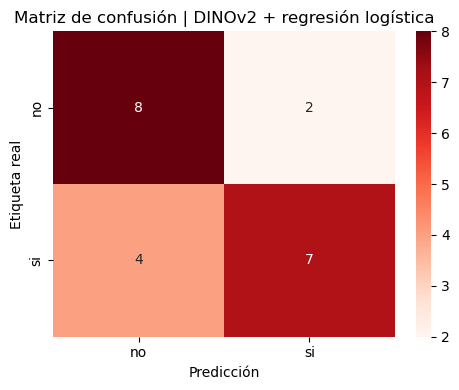

In [39]:
cm = metrics["confusion_matrix"]

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=[NEGATIVE_LABEL, POSITIVE_LABEL],
    yticklabels=[NEGATIVE_LABEL, POSITIVE_LABEL],
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión | DINOv2 + regresión logística")
plt.tight_layout()
plt.show()

## Preparar puntos de umbral para las curvas

Para que las curvas sean más interpretables, marcamos varios umbrales concretos sobre la línea en lugar de mostrar todos los posibles.

In [40]:
def build_threshold_marker_df(
    curve_thresholds,
    x_values,
    y_values,
    thresholds_to_mark=None,
):
    if thresholds_to_mark is None:
        thresholds_to_mark = np.array([0.2, 0.4, 0.5, 0.6, 0.8])

    marker_rows = []

    for threshold in thresholds_to_mark:
        closest_idx = int(np.argmin(np.abs(curve_thresholds - threshold)))
        marker_rows.append(
            {
                "threshold_target": float(threshold),
                "threshold_curve": float(curve_thresholds[closest_idx]),
                "x": float(x_values[closest_idx]),
                "y": float(y_values[closest_idx]),
            }
        )

    return pd.DataFrame(marker_rows).drop_duplicates(subset=["threshold_curve"])

## ROC y AUC

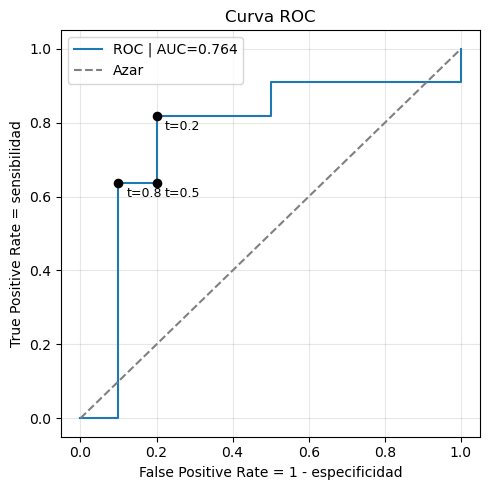

In [41]:
y_test_binary = (y_test == POSITIVE_LABEL).astype(int)
fpr, tpr, roc_thresholds = roc_curve(y_test_binary, y_score)
roc_marker_df = build_threshold_marker_df(
    curve_thresholds=roc_thresholds,
    x_values=fpr,
    y_values=tpr,
)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC | AUC={metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
plt.scatter(roc_marker_df["x"], roc_marker_df["y"], color="black", s=35, zorder=3)

for _, row in roc_marker_df.iterrows():
    plt.annotate(
        f"t={row['threshold_target']:.1f}",
        (row["x"], row["y"]),
        textcoords="offset points",
        xytext=(6, -10),
        fontsize=9,
    )

plt.xlabel("False Positive Rate = 1 - especificidad")
plt.ylabel("True Positive Rate = sensibilidad")
plt.title("Curva ROC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Precision-Recall y Average Precision

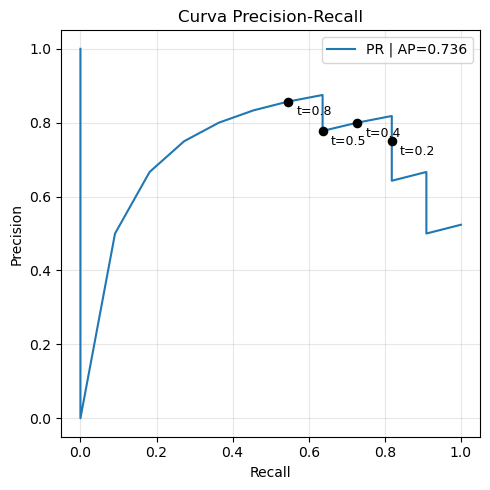

In [42]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test_binary, y_score)
pr_marker_df = build_threshold_marker_df(
    curve_thresholds=pr_thresholds,
    x_values=recall_curve[:-1],
    y_values=precision_curve[:-1],
)

plt.figure(figsize=(5, 5))
plt.plot(recall_curve, precision_curve, label=f"PR | AP={metrics['average_precision']:.3f}")
plt.scatter(pr_marker_df["x"], pr_marker_df["y"], color="black", s=35, zorder=3)

for _, row in pr_marker_df.iterrows():
    plt.annotate(
        f"t={row['threshold_target']:.1f}",
        (row["x"], row["y"]),
        textcoords="offset points",
        xytext=(6, -10),
        fontsize=9,
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cómo cambian precision y recall con el umbral

Las curvas anteriores usan todos los umbrales posibles. Aquí lo hacemos más tangible mostrando varias decisiones de corte sobre la probabilidad de `si`.

In [43]:
thresholds_to_check = np.linspace(0.1, 0.9, 9)
threshold_rows = []

for threshold in thresholds_to_check:
    y_pred_threshold = np.where(y_score >= threshold, POSITIVE_LABEL, NEGATIVE_LABEL)
    threshold_metrics = compute_binary_metrics(
        y_true=y_test,
        y_pred=y_pred_threshold,
        y_score=y_score,
        positive_label=POSITIVE_LABEL,
        negative_label=NEGATIVE_LABEL,
    )
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": threshold_metrics["precision"],
            "recall": threshold_metrics["recall"],
            "specificity": threshold_metrics["specificity"],
            "f1": threshold_metrics["f1"],
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.round(3)

,threshold,precision,recall,specificity,f1
0,0.1,0.692,0.818,0.6,0.750
1,0.2,0.818,0.818,0.8,0.818
2,0.3,0.818,0.818,0.8,0.818
3,0.4,0.778,0.636,0.8,0.700
4,0.5,0.778,0.636,0.8,0.700
5,0.6,0.875,0.636,0.9,0.737
6,0.7,0.857,0.545,0.9,0.667
7,0.8,0.857,0.545,0.9,0.667
8,0.9,0.800,0.364,0.9,0.500


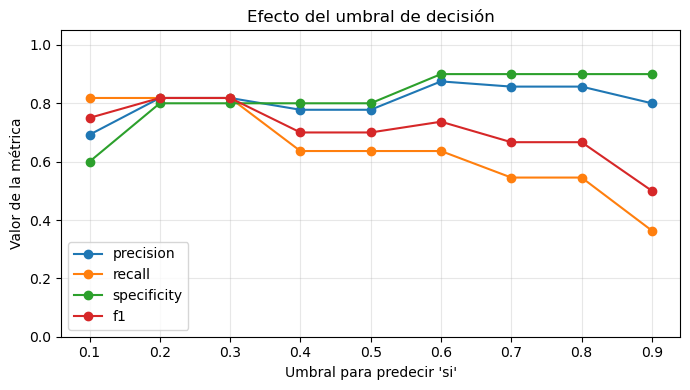

In [44]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["threshold"], threshold_df["specificity"], marker="o", label="specificity")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")
plt.xlabel("Umbral para predecir 'si'")
plt.ylabel("Valor de la métrica")
plt.title("Efecto del umbral de decisión")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Analizar algunos errores

In [45]:
analysis_df = test_predictions_df.copy()
analysis_df["acierto"] = analysis_df["etiqueta"] == analysis_df["prediccion"]
analysis_df["image"] = test_df["image"]
analysis_df["image_crop"] = test_df["image_crop"]

errores_df = analysis_df[analysis_df["acierto"] == False].reset_index(drop=True)
errores_df[["archivo", "etiqueta", "prediccion", "score_si"]].head()

,archivo,etiqueta,prediccion,score_si
0,img_1776863881713.png,si,no,2.896845e-02
1,img_1777027208507.png,no,si,9.892105e-01
2,img_1777028264615.png,si,no,3.663139e-01
3,img_1776863516809.png,si,no,3.261101e-01
4,img_1776940961519.png,si,no,4.439606e-07


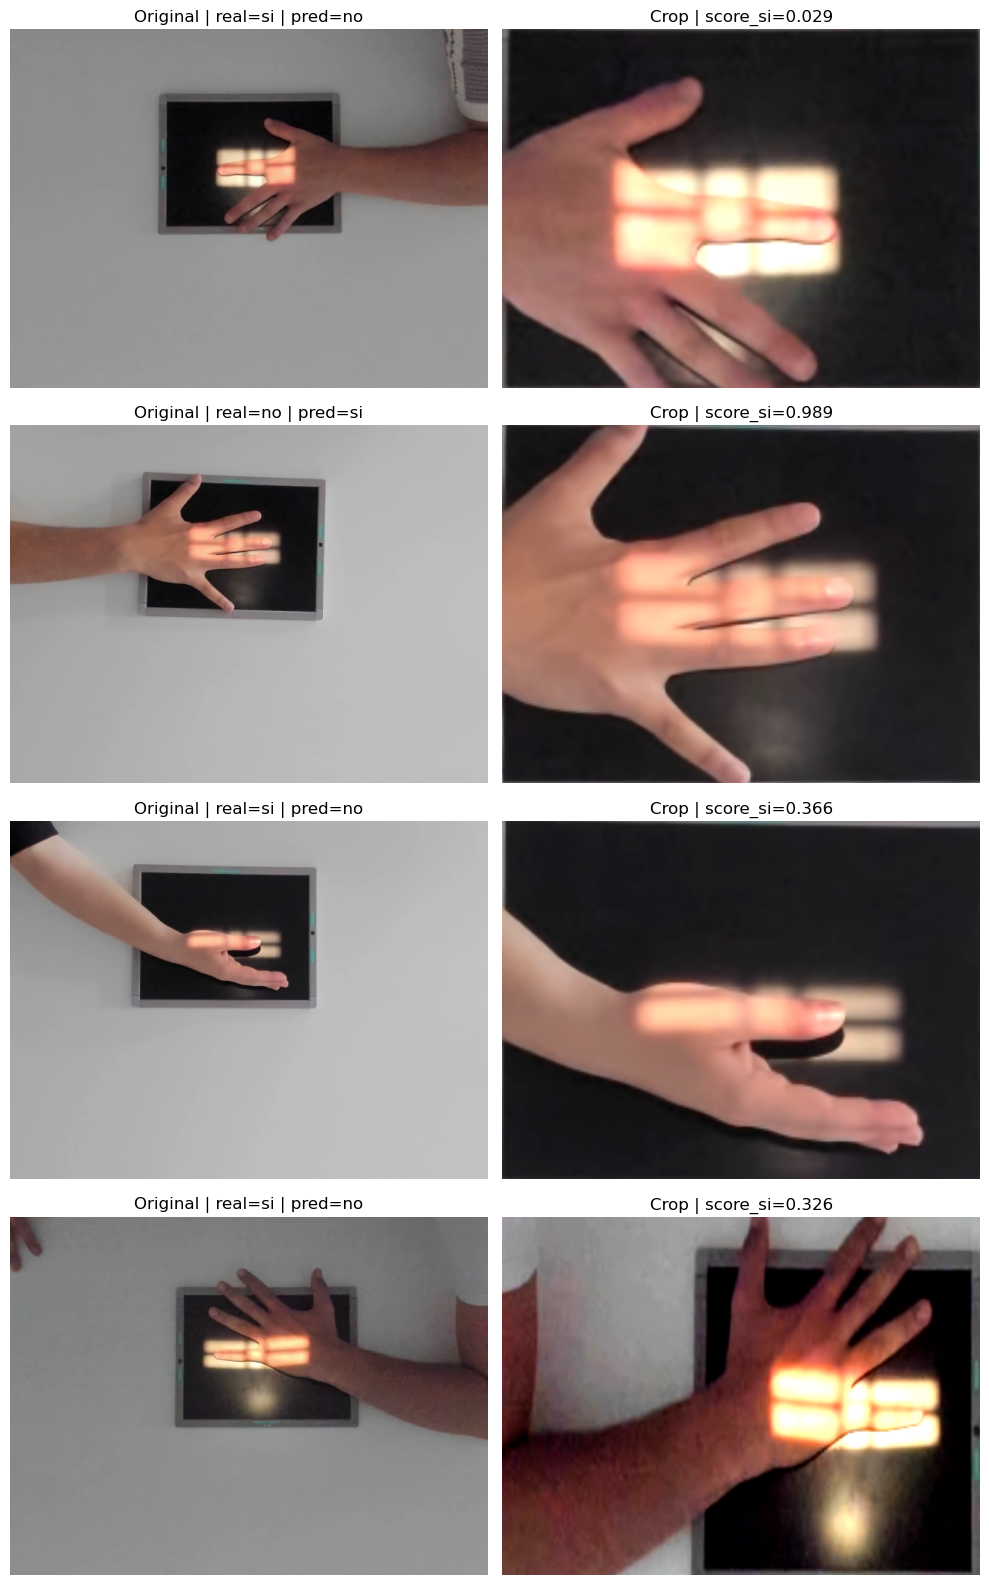

In [46]:
num_errors_to_show = min(4, len(errores_df))

if num_errors_to_show == 0:
    print("No hay errores en este conjunto de test con el umbral actual.")
else:
    fig, axes = plt.subplots(num_errors_to_show, 2, figsize=(10, 4 * num_errors_to_show))
    axes = np.atleast_2d(axes)

    for row_idx in range(num_errors_to_show):
        row = errores_df.iloc[row_idx]
        axes[row_idx, 0].imshow(row["image"])
        axes[row_idx, 0].set_title(f"Original | real={row['etiqueta']} | pred={row['prediccion']}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(row["image_crop"])
        axes[row_idx, 1].set_title(f"Crop | score_si={row['score_si']:.3f}")
        axes[row_idx, 1].axis("off")

    plt.tight_layout()
    plt.show()

## Guardar las predicciones del test

Esto puede ser útil si luego quieres comparar este modelo con otros modelos o con otras vistas.

In [47]:
output_path = Path("resultados/day4_dinov2_evaluation_test_pred.csv")
test_predictions_df.to_csv(output_path, index=False)
output_path

WindowsPath('resultados/day4_dinov2_evaluation_test_pred.csv')

## Conclusiones

En este notebook hemos evaluado el mismo tipo de modelo que usa la app final:

- `DINOv2` como extractor de embeddings globales;
- regresión logística como clasificador ligero;
- panel rectificado como entrada más estable.

Además de la accuracy, ahora ya tenemos una visión más completa del comportamiento del sistema:

- la matriz de confusión nos dice qué tipo de errores comete;
- precision, recall y F1 resumen el rendimiento sobre la clase positiva;
- sensibilidad y especificidad separan bien los dos tipos de acierto clínicamente relevantes;
- ROC/AUC y PR/AP muestran cómo cambia el modelo al mover el umbral.

Como siguiente paso natural, se puede repetir exactamente este mismo cuaderno para otras carpetas del curso como `mano`, `muñeca` o las vistas laterales, y comparar resultados de forma homogénea.